In [1]:
import pandas as pd
df = pd.read_csv('homework.csv')
df

,Person,Activity_Type,Calories_Burned,Steps,Hours_Slept,Mood
0,Aria,Walking,248,8079,9.2,Happy
1,Aria,Swimming,565,3419,6.7,Happy
2,Aria,Running,539,5173,5.4,Tired
3,Milo,Running,475,7911,7.2,Tired
4,Milo,Hiking,402,12084,7.7,Energetic
...,...,...,...,...,...,...
70,Elise,Swimming,377,3156,6.9,Focused
71,Elise,Running,557,9448,7.1,Happy
72,Dante,Swimming,440,3033,8.6,Focused
73,Dante,Strength Training,381,3449,6.7,Energetic


Column chart - Average calories burned by activity type

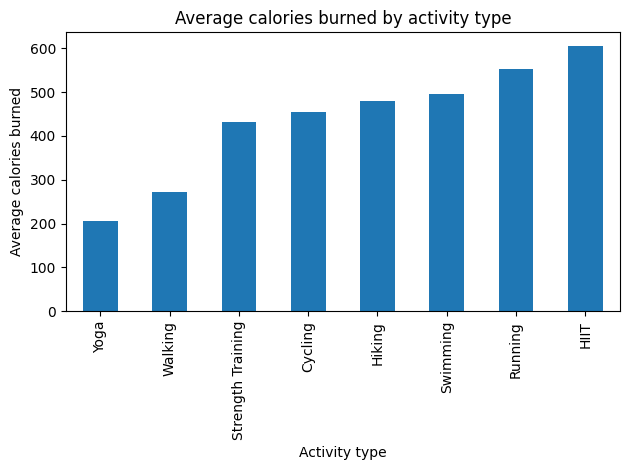

In [2]:
import matplotlib.pyplot as plt

plt.figure()
cal_by_act = df.groupby("Activity_Type")["Calories_Burned"].mean().sort_values()
cal_by_act.plot(kind="bar", title="Average calories burned by activity type")
plt.xlabel("Activity type")
plt.ylabel("Average calories burned")
plt.tight_layout()
plt.show()

Reflection: The most energy-intensive activities are HIIT, running, and swimming, while yoga and walking result in lower average calorie burn.
This aligns with expectations: high-intensity activities typically consume more energy.

Pie chart - Mood distribution

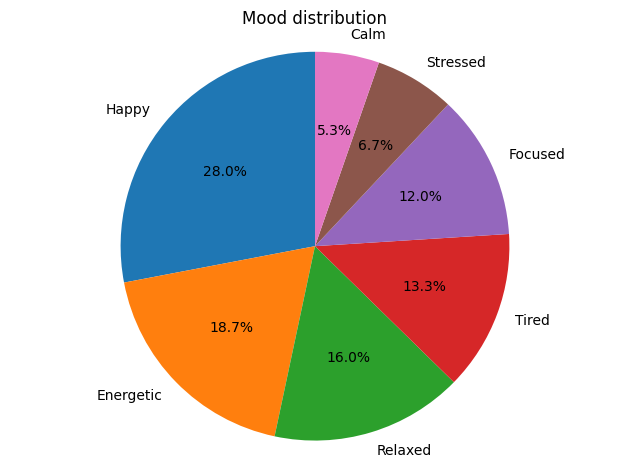

In [3]:
plt.figure()
mood_counts = df["Mood"].value_counts()
plt.pie(mood_counts.values, labels=mood_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Mood distribution")
plt.axis("equal")
plt.tight_layout()
plt.show()

Reflection: The most common moods are Happy, Energetic, and Focused, while calm and stressed are two the least frequent ones.
We can infer that the overall mood in the dataset is positive, possibly suggesting that physical activity supports emotional well-being.

Bubble plot - steps vs calories Burned (size=sleep)

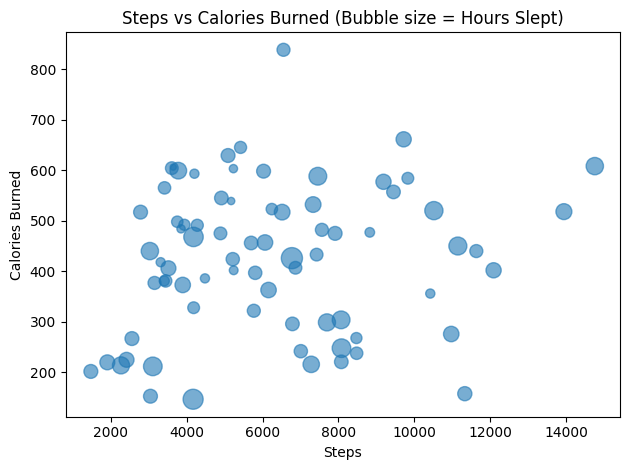

In [4]:
plt.figure()
sizes = (df["Hours_Slept"] - df["Hours_Slept"].min() + 0.5) * 40  
plt.scatter(df["Steps"], df["Calories_Burned"], s=sizes, alpha=0.6)
plt.title("Steps vs Calories Burned (Bubble size = Hours Slept)")
plt.xlabel("Steps")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.show()

Reflection: There is a general trend: more steps -> more calories burned.
However, there’s noticeable variation. For example, swimming or strength training can burn many calories even without a large number of steps.
Larger bubbles (indicating more hours of sleep) do not seem to directly increase calories burned, suggesting that sleep is an independent factor.

Box Plot - Hours slept by activity type

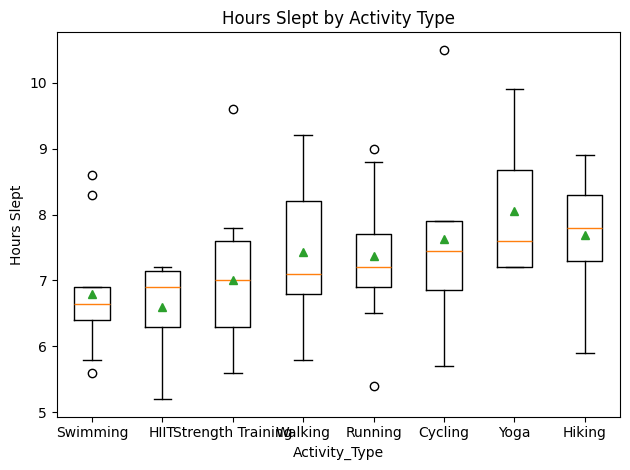

In [5]:
plt.figure()
order = df.groupby("Activity_Type")["Hours_Slept"].median().sort_values().index.tolist()
data_for_box = [df[df["Activity_Type"] == act]["Hours_Slept"].values for act in order]
plt.boxplot(data_for_box, labels=order, showmeans=True)
plt.title("Hours Slept by Activity Type")
plt.xlabel("Activity_Type")
plt.ylabel("Hours Slept")
plt.tight_layout()
plt.show()

Reflection: The walking and yoga groups have slightly higher median sleep hours, while HIIT and strength training are a bit lower.
Sleep tends to fluctuate after intense workouts, but overall, it remains in a healthy range of about 6.5 to 8.5 hours.

Line chart - Average sleep hours by mood

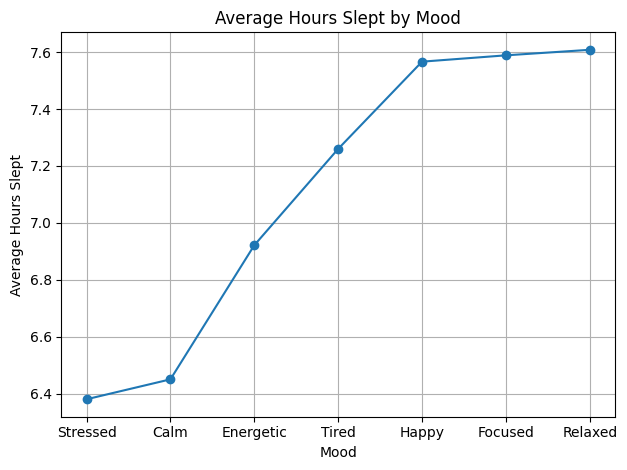

In [6]:
plt.figure()
avg_sleep_by_mood = df.groupby("Mood")["Hours_Slept"].mean().sort_values()
avg_sleep_by_mood.plot(kind="line", marker="o", title="Average Hours Slept by Mood")
plt.xlabel("Mood")
plt.ylabel("Average Hours Slept")
plt.grid(True)
plt.tight_layout()
plt.show()

Reflection: This line chart shows that people who report being calm, relaxed, or happy tend to have slightly longer sleep durations.
In contrast, Stressed and tired mood correspond to fewer hours of sleep.
It suggests that sufficient sleep may support better mood and emotional balance.

Histogram - Distribution of calories burned

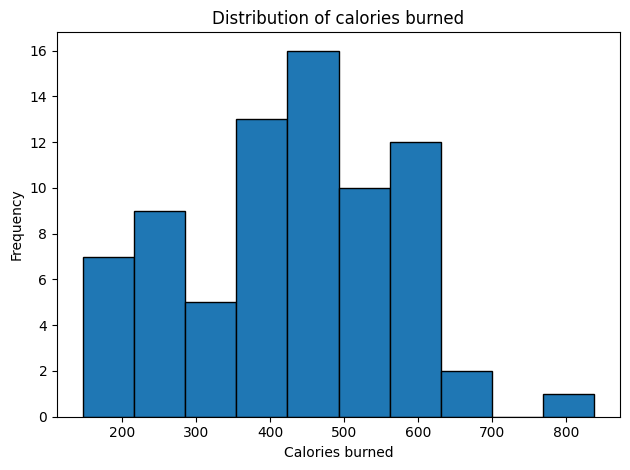

In [7]:
plt.figure()
plt.hist(df["Calories_Burned"], bins=10, edgecolor="black")
plt.title("Distribution of calories burned")
plt.xlabel("Calories burned")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Reflection: The histogram reveals that most activity sessions burn between 350–550 calories, with fewer extremely high or low values.
This distribution is roughly bell-shaped, suggesting a consistent level of moderate to high intensity across activities.
There are some higher-calorie outliers (likely from HIIT or Swimming), which add variety to the dataset.

Horizontal bar chart – Average steps by activity type

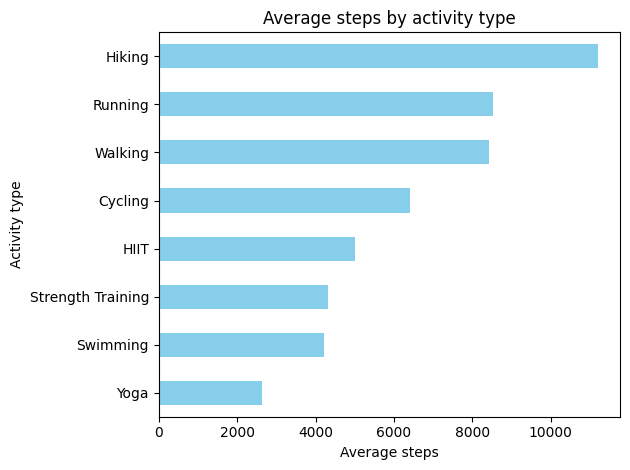

In [8]:
plt.figure()
steps_by_activity = df.groupby("Activity_Type")["Steps"].mean().sort_values()
steps_by_activity.plot(kind="barh", color="skyblue", title="Average steps by activity type")
plt.xlabel("Average steps")
plt.ylabel("Activity type")
plt.tight_layout()
plt.show()

Reflection: This horizontal bar chart shows that hiking, walking, and running generate the highest step counts,
while yoga and swimming involve far fewer steps.
It highlights that calorie burn is not solely tied to step count, some low-step activities can still be quite intense.